    # Black Friday Sales Analysis - Age and Marital Status Analysis

    ## Objective
    Study the effect of age and marital status on customer purchase behavior and identify high-value customer groups.

    ## Steps Performed
    - Analyzed age-group distribution
- Compared purchase behavior across age groups
- Studied marital status patterns
- Combined age and marital status for deeper analysis

    ## Insights
    - Certain age groups contribute more strongly to revenue
- Marital status adds useful context to customer behavior
- Segment-based analysis helps understand purchasing patterns better


In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('BlackFriday.csv')

del df['Product_Category_2']
del df['Product_Category_3']

In [3]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [4]:
df.groupby('Age').size()

Age
0-17      14707
18-25     97634
26-35    214690
36-45    107499
46-50     44526
51-55     37618
55+       20903
dtype: int64

<Axes: title={'center': 'Purchase Distribution By Age'}, xlabel='Age'>

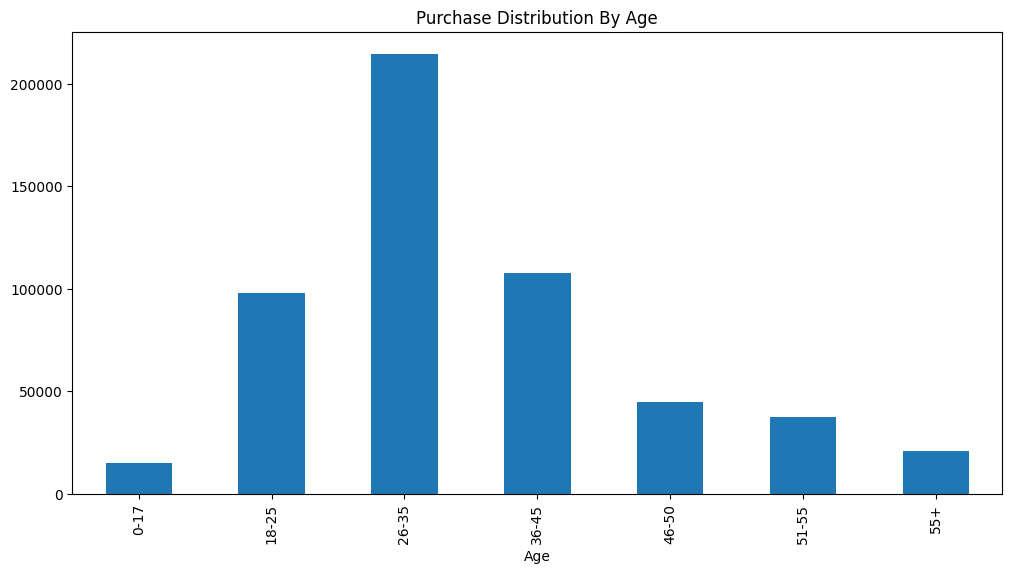

In [6]:
df.groupby('Age').size().plot(kind='bar',figsize=(12,6),title='Purchase Distribution By Age')

In [8]:
for i in df['Age'].unique():
    print(i)

0-17
55+
26-35
46-50
51-55
36-45
18-25


In [9]:
df[df['Age']=='0-17']

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
85,1000019,P00112542,M,0-17,10,A,3,0,1,7746
...,...,...,...,...,...,...,...,...,...,...
537280,1004690,P00242742,F,0-17,10,C,3,0,1,11561
537281,1004690,P00226442,F,0-17,10,C,3,0,11,6010
537282,1004690,P00181442,F,0-17,10,C,3,0,11,7458
537283,1004690,P00192042,F,0-17,10,C,3,0,5,3706


In [10]:
len(df[df['Age']=='0-17'])

14707

In [12]:
for i in df['Age'].unique():
    print(i,':',len(df[df['Age']==i]))

0-17 : 14707
55+ : 20903
26-35 : 214690
46-50 : 44526
51-55 : 37618
36-45 : 107499
18-25 : 97634


In [13]:
df[df['Age']==i]

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
70,1000018,P00366542,F,18-25,3,B,3,0,5,1780
71,1000018,P00190742,F,18-25,3,B,3,0,3,10754
72,1000018,P00151842,F,18-25,3,B,3,0,4,2802
73,1000018,P00112642,F,18-25,3,B,3,0,1,19473
74,1000018,P00118442,F,18-25,3,B,3,0,1,19672
...,...,...,...,...,...,...,...,...,...,...
537566,1004736,P00048742,M,18-25,20,A,1,1,5,5350
537567,1004736,P00157542,M,18-25,20,A,1,1,8,1994
537568,1004736,P00250642,M,18-25,20,A,1,1,11,5930
537569,1004736,P00023142,M,18-25,20,A,1,1,5,7042


In [15]:
i

'18-25'

In [14]:
df[df['Age']==i]['Product_ID']

70        P00366542
71        P00190742
72        P00151842
73        P00112642
74        P00118442
            ...    
537566    P00048742
537567    P00157542
537568    P00250642
537569    P00023142
537570    P00162442
Name: Product_ID, Length: 97634, dtype: object

In [17]:
df[df['Age']==i]['Product_ID'].nunique()

3213

In [20]:
for i in df['Age'].unique():
    print(i,':',len(df[df['Age']==i]['Product_ID'].unique()))

0-17 : 2300
55+ : 2573
26-35 : 3419
46-50 : 3099
51-55 : 2877
36-45 : 3318
18-25 : 3213


In [27]:
lst=[]
for i in df['Age'].unique():
    lst.append([i,len(df[df['Age']==i]['Product_ID'].unique())])

data=pd.DataFrame(lst,columns=['Age','Products'])

In [28]:
data

,Age,Products
0,0-17,2300
1,55+,2573
2,26-35,3419
3,46-50,3099
4,51-55,2877
5,36-45,3318
6,18-25,3213


<Axes: >

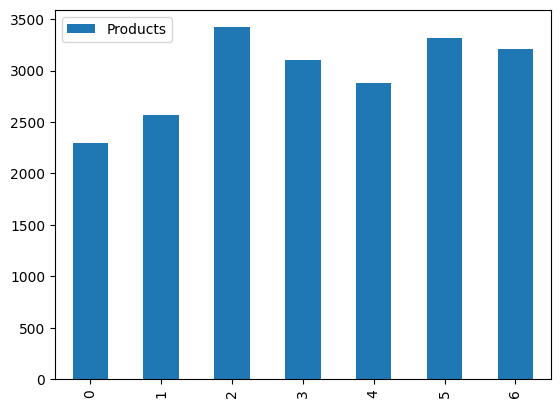

In [29]:
data.plot(kind='bar')

<Axes: xlabel='Age'>

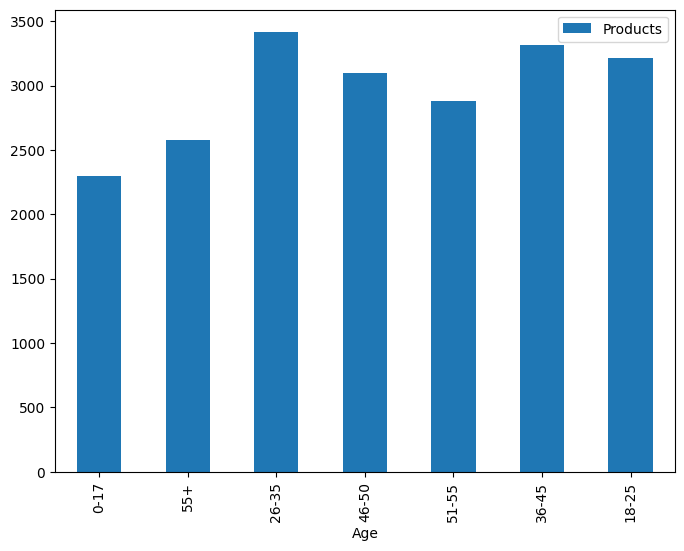

In [32]:
data.plot(kind='bar',x='Age',figsize=(8,6))

In [35]:
df[df['Age']=='0-17'].sum()

User_ID                                                             14746359773
Product_ID                    P00069042P00248942P00087842P00085442P00112542P...
Gender                        FFFFMMMMMMMMMMMMFFFFFFFFFFFFFFFFFFFFFFFMMMFFFF...
Age                           0-170-170-170-170-170-170-170-170-170-170-170-...
Occupation                                                               129278
City_Category                 AAAAAAAAAAAAAAAACCCCCCCCCCCCCCCCCCCCCCCCCCCCCC...
Stay_In_Current_City_Years    222233333333333324+4+4+4+4+4+4+4+4+4+331111111...
Marital_Status                                                                0
Product_Category_1                                                        72599
Purchase                                                              132659006
dtype: object

<Axes: title={'center': 'Amount Spend By Age'}, xlabel='Age'>

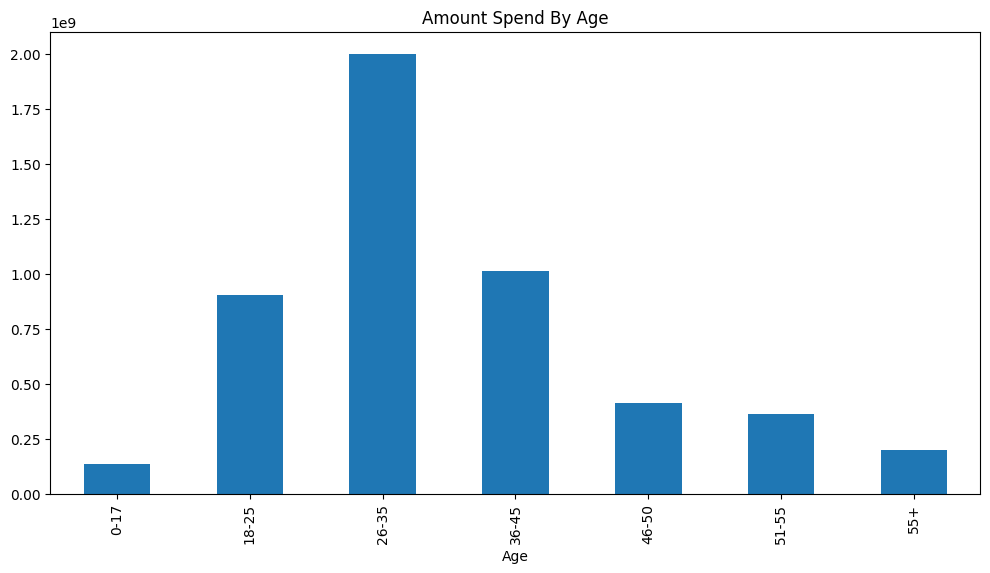

In [41]:
df.groupby('Age')['Purchase'].sum().plot(kind='bar',figsize=(12,6),title=('Amount Spend By Age'))

<Axes: title={'center': 'Amount Spend By Age'}, xlabel='Age'>

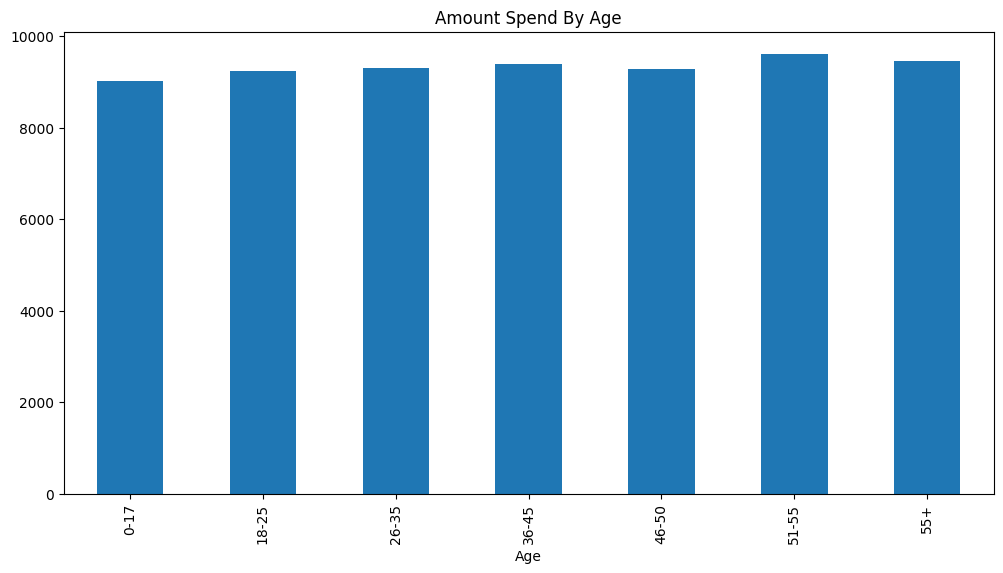

In [43]:
df.groupby('Age')['Purchase'].mean().plot(kind='bar',figsize=(12,6),title=('Amount Spend By Age'))

In [44]:
df.groupby('Age')['Purchase'].mean()

Age
0-17     9020.126878
18-25    9235.197575
26-35    9314.588970
36-45    9401.478758
46-50    9284.872277
51-55    9620.616620
55+      9453.898579
Name: Purchase, dtype: float64

<Axes: ylabel='Purchase'>

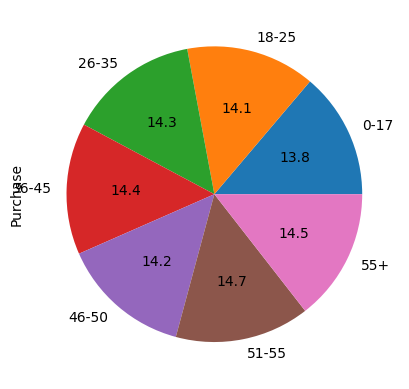

In [46]:
df.groupby('Age')['Purchase'].mean().plot(kind='pie',autopct='%.1f')

<Axes: >

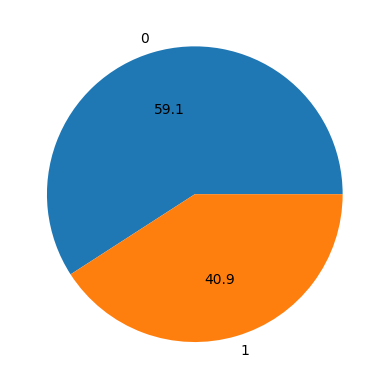

In [47]:
df.groupby('Marital_Status').size().plot(kind='pie', autopct='%.1f')

<Axes: >

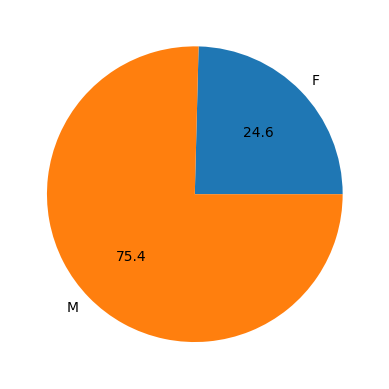

In [48]:
df.groupby('Gender').size().plot(kind='pie', autopct='%.1f')

## Extra Visuals
Additional visuals for age and marital status analysis.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'Age' in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x='Age', data=df)
    plt.title("Customer Count by Age Group")
    plt.xticks(rotation=45)
    plt.show()

    if 'Purchase' in df.columns:
        plt.figure(figsize=(8,4))
        df.groupby('Age')['Purchase'].mean().plot(kind='bar')
        plt.title("Average Purchase by Age Group")
        plt.ylabel("Average Purchase")
        plt.xticks(rotation=45)
        plt.show()

if 'Marital_Status' in df.columns and 'Purchase' in df.columns:
    plt.figure(figsize=(6,4))
    sns.barplot(x='Marital_Status', y='Purchase', data=df, estimator=np.mean)
    plt.title("Average Purchase by Marital Status")
    plt.show()


## Notebook Summary
This notebook explains how age and marital status relate to purchase behavior.

## Suggested Next Step
Link these insights with occupation or product categories for stronger business understanding.